# Card Pipeline

This notebook processes the reference images in several steps:
1. load saved HSV and Canny settings,
2. threshold one reference image for each color,
3. apply Canny with saved settings,
4. detect rectangle candidates,
5. extract the best rectangle from the original image,
6. run the batch pipeline and save all cards.

In [22]:
from __future__ import annotations

import re
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


BASE_DIR = Path.cwd()
DATASET_DIR = BASE_DIR / "iapr-26-uno-vision-challenge"
REFERENCE_DIR = DATASET_DIR / "reference_images"
CARDS_DIR = DATASET_DIR / "cards"
COLORS = ("blue", "red", "yellow", "black")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
HSV_ARRAY_PATTERN = re.compile(r"np\.array\(\s*\[([^\]]+)\]\s*\)")
CANNY_PATTERN = re.compile(r"^\s*([^:]+)\s*:\s*(\d+)\s*$", re.MULTILINE)
HOUGH_PATTERN = re.compile(r"^\s*([^:]+)\s*:\s*(\d+)\s*$", re.MULTILINE)
SCALE = 0.25

CARDS_DIR.mkdir(parents=True, exist_ok=True)

# Change this when you want to inspect another reference image.
SAMPLE_IMAGE_NAME = "L1000768.jpg"


def parse_hsv_file(path: Path) -> list[tuple[np.ndarray, np.ndarray]]:
    text = path.read_text(encoding="utf-8")
    arrays = []
    for match in HSV_ARRAY_PATTERN.finditer(text):
        values = [int(value.strip()) for value in match.group(1).split(",")]
        arrays.append(np.array(values, dtype=np.uint8))
    if len(arrays) % 2 != 0 or not arrays:
        raise ValueError(f"Expected lower/upper HSV pairs in {path}")
    return list(zip(arrays[0::2], arrays[1::2]))


def load_hsv_thresholds() -> dict[str, list[tuple[np.ndarray, np.ndarray]]]:
    return {color: parse_hsv_file(BASE_DIR / f"{color}_hsv.txt") for color in COLORS}


def load_canny_settings(path: Path) -> dict[str, int]:
    text = path.read_text(encoding="utf-8")
    settings = {key.strip().lower().replace(" ", "_"): int(value) for key, value in CANNY_PATTERN.findall(text)}
    required = {"blur", "low", "high", "min_len"}
    missing = required - settings.keys()
    if missing:
        raise ValueError(f"Missing Canny settings in {path}: {sorted(missing)}")
    if settings["blur"] % 2 == 0:
        settings["blur"] += 1
    return settings


def load_hough_settings(path: Path) -> dict[str, int]:
    text = path.read_text(encoding="utf-8")
    settings = {key.strip().lower().replace(" ", "_"): int(value) for key, value in HOUGH_PATTERN.findall(text)}
    required = {"threshold", "min_line", "max_gap", "min_peri", "min_size"}
    missing = required - settings.keys()
    if missing:
        raise ValueError(f"Missing Hough settings in {path}: {sorted(missing)}")
    return settings


def threshold_image(image_bgr: np.ndarray, ranges: list[tuple[np.ndarray, np.ndarray]]) -> np.ndarray:
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    combined_mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        combined_mask = cv2.bitwise_or(combined_mask, cv2.inRange(hsv, lower, upper))
    return combined_mask


def filter_short_contours(edges: np.ndarray, min_length: int) -> np.ndarray:
    if min_length <= 0:
        return edges
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    filtered = np.zeros_like(edges)
    for contour in contours:
        if cv2.arcLength(contour, closed=True) >= min_length:
            cv2.drawContours(filtered, [contour], -1, 255, thickness=2)
    return filtered


def canny_mask(mask: np.ndarray, settings: dict[str, int]) -> np.ndarray:
    blurred = cv2.GaussianBlur(mask, (settings["blur"], settings["blur"]), 0)
    edges = cv2.Canny(blurred, settings["low"], settings["high"])
    edges = filter_short_contours(edges, settings["min_len"])
    return cv2.dilate(edges, np.ones((3, 3), dtype=np.uint8), iterations=1)


def collect_rectangle_candidates(contours: list[np.ndarray], hough_settings: dict[str, int]) -> list[tuple[float, np.ndarray, tuple[int, int, int, int]]]:
    candidates = []
    for contour in contours:
        perimeter = cv2.arcLength(contour, True)
        if perimeter < hough_settings["min_peri"]:
            continue
        rect = cv2.minAreaRect(contour)
        (_, _), (width, height), _ = rect
        if width < hough_settings["min_size"] or height < hough_settings["min_size"]:
            continue
        long_side = max(width, height)
        short_side = min(width, height)
        if short_side == 0:
            continue
        area = cv2.contourArea(contour)
        rect_area = width * height
        fill_ratio = area / rect_area if rect_area > 0 else 0.0
        aspect_ratio = long_side / short_side
        score = perimeter * fill_ratio * min(aspect_ratio, 3.0)
        box = cv2.boxPoints(rect).astype(np.float32)
        x, y, w, h = cv2.boundingRect(box.astype(np.int32))
        box_area = w * h
        score *= rect_area / box_area if box_area > 0 else 1.0
        candidates.append((score, box, (x, y, w, h)))
    candidates.sort(key=lambda item: item[0], reverse=True)
    return candidates


def detect_rectangles(edge_image: np.ndarray, hough_settings: dict[str, int]) -> tuple[np.ndarray, list[tuple[float, np.ndarray, tuple[int, int, int, int]]]]:
    small_edges = cv2.resize(edge_image, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_NEAREST)
    prepped_edges = small_edges.copy()
    line_canvas = cv2.cvtColor(small_edges, cv2.COLOR_GRAY2RGB)
    line_mask = np.zeros_like(small_edges)
    lines = cv2.HoughLinesP(
        prepped_edges,
        rho=1,
        theta=np.pi / 180,
        threshold=hough_settings["threshold"],
        minLineLength=hough_settings["min_line"],
        maxLineGap=hough_settings["max_gap"],
    )
    if lines is None:
        return line_canvas, []
    for line in lines[:, 0]:
        x1, y1, x2, y2 = line
        cv2.line(line_canvas, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.line(line_mask, (x1, y1), (x2, y2), 255, 2)
    contours, _ = cv2.findContours(line_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidates = collect_rectangle_candidates(contours, hough_settings)
    return line_canvas, candidates


def order_box_points(points: np.ndarray) -> np.ndarray:
    points = np.array(points, dtype=np.float32)
    sums = points.sum(axis=1)
    diffs = np.diff(points, axis=1).ravel()
    ordered = np.zeros((4, 2), dtype=np.float32)
    ordered[0] = points[np.argmin(sums)]
    ordered[2] = points[np.argmax(sums)]
    ordered[1] = points[np.argmin(diffs)]
    ordered[3] = points[np.argmax(diffs)]
    return ordered


def extract_rotated_rectangle(image_bgr: np.ndarray, box_small: np.ndarray, scale: float = SCALE) -> np.ndarray:
    box_full = box_small / scale
    ordered = order_box_points(box_full)
    width_a = np.linalg.norm(ordered[2] - ordered[3])
    width_b = np.linalg.norm(ordered[1] - ordered[0])
    height_a = np.linalg.norm(ordered[1] - ordered[2])
    height_b = np.linalg.norm(ordered[0] - ordered[3])
    width = max(1, int(round(max(width_a, width_b))))
    height = max(1, int(round(max(height_a, height_b))))
    destination = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], dtype=np.float32)
    transform = cv2.getPerspectiveTransform(ordered, destination)
    return cv2.warpPerspective(image_bgr, transform, (width, height))


def reference_images(reference_dir: Path) -> list[Path]:
    return [path for path in sorted(reference_dir.iterdir()) if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS]


def show_images(images: list[tuple[str, np.ndarray]], cmap: str | None = None, cols: int = 2, figsize: tuple[int, int] = (14, 10)) -> None:
    rows = int(np.ceil(len(images) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, (title, image) in zip(axes, images):
        if image.ndim == 2:
            ax.imshow(image, cmap=cmap or "gray")
        else:
            ax.imshow(image)
        ax.set_title(title)
        ax.axis("off")
    for ax in axes[len(images):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


Loaded 4 reference images
Canny settings: {'blur': 1, 'low': 40, 'high': 59, 'min_len': 210}
Hough settings: {'threshold': 57, 'min_line': 60, 'max_gap': 23, 'min_peri': 400, 'min_size': 60}
Sample image: L1000768.jpg


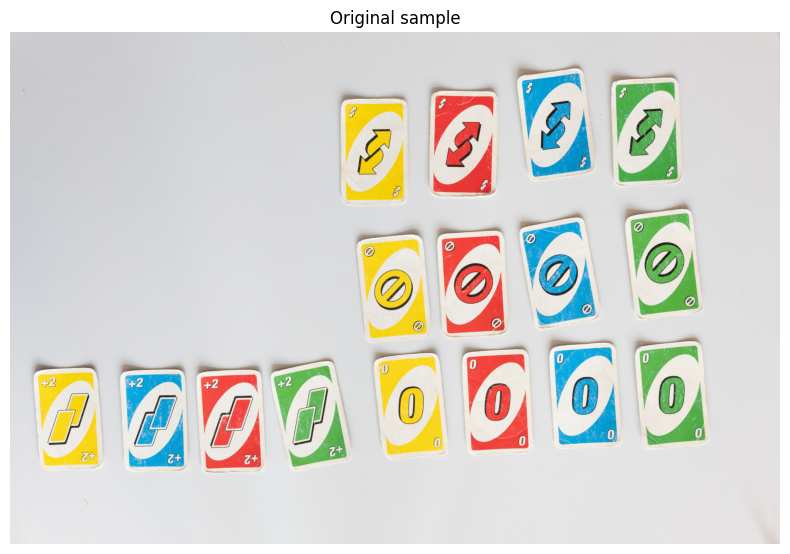

In [23]:
hsv_thresholds = load_hsv_thresholds()
canny_settings = load_canny_settings(BASE_DIR / "canny_set.txt")
hough_settings = load_hough_settings(BASE_DIR / "hough_set.txt")
images = reference_images(REFERENCE_DIR)
sample_path = REFERENCE_DIR / SAMPLE_IMAGE_NAME
sample_bgr = cv2.imread(str(sample_path))
if sample_bgr is None:
    raise FileNotFoundError(f"Could not load sample image: {sample_path}")
sample_rgb = cv2.cvtColor(sample_bgr, cv2.COLOR_BGR2RGB)

print(f"Loaded {len(images)} reference images")
print("Canny settings:", canny_settings)
print("Hough settings:", hough_settings)
print("Sample image:", sample_path.name)
show_images([("Original sample", sample_rgb)], cols=1, figsize=(8, 8))


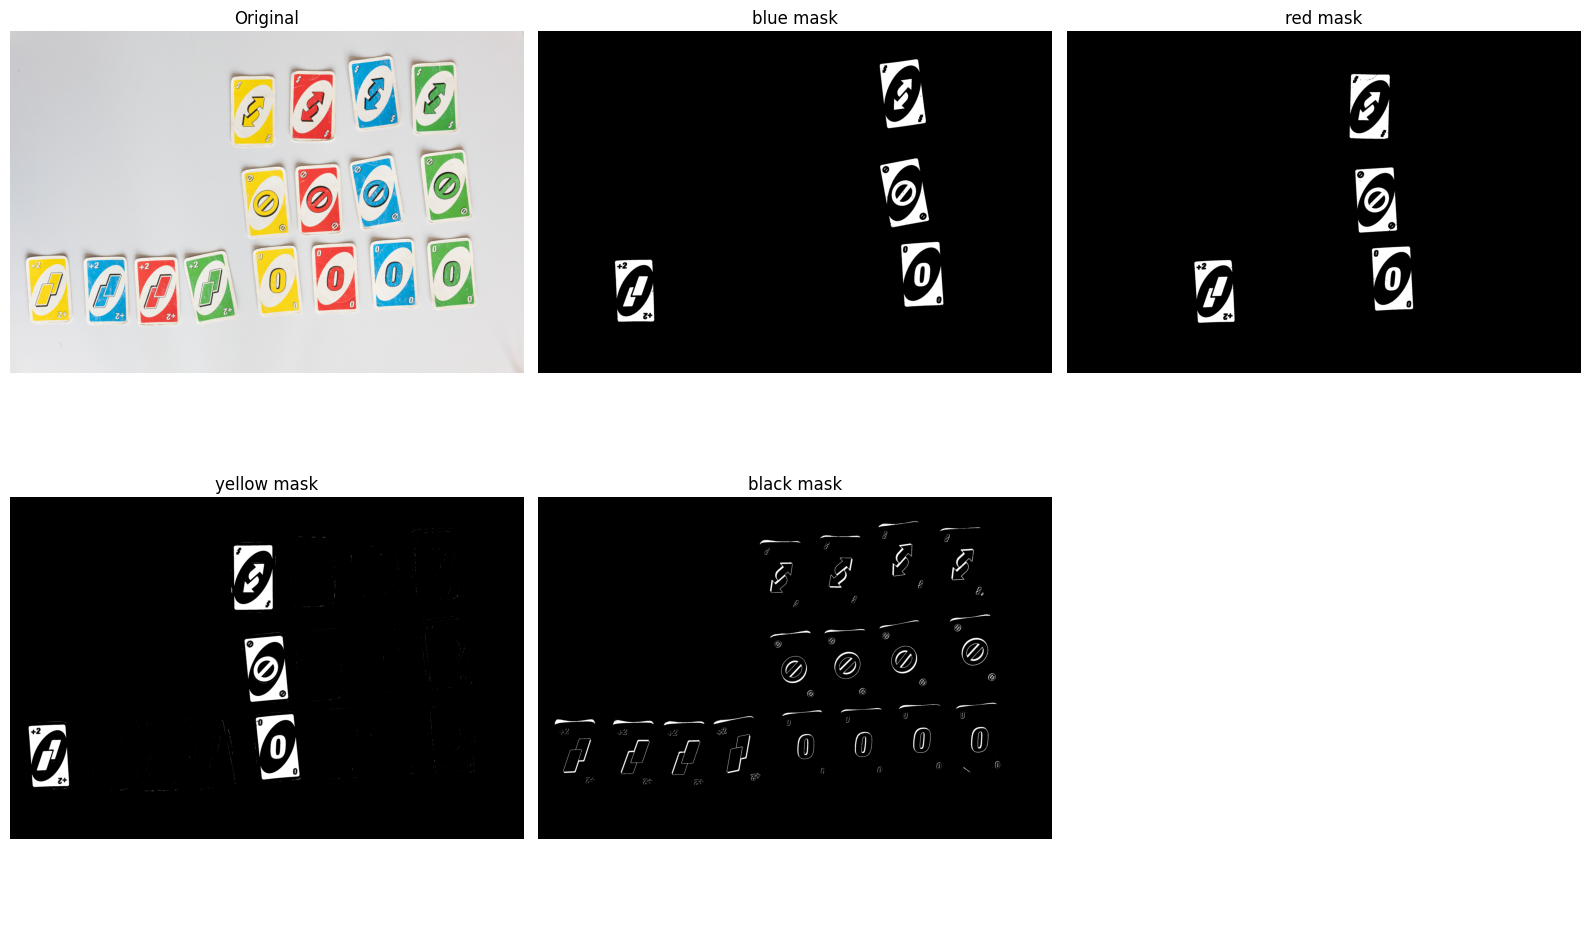

In [24]:
sample_masks = {}
threshold_views = [("Original", sample_rgb)]

for color in COLORS:
    mask = threshold_image(sample_bgr, hsv_thresholds[color])
    sample_masks[color] = mask
    threshold_views.append((f"{color} mask", mask))

show_images(threshold_views, cols=3, figsize=(16, 10))


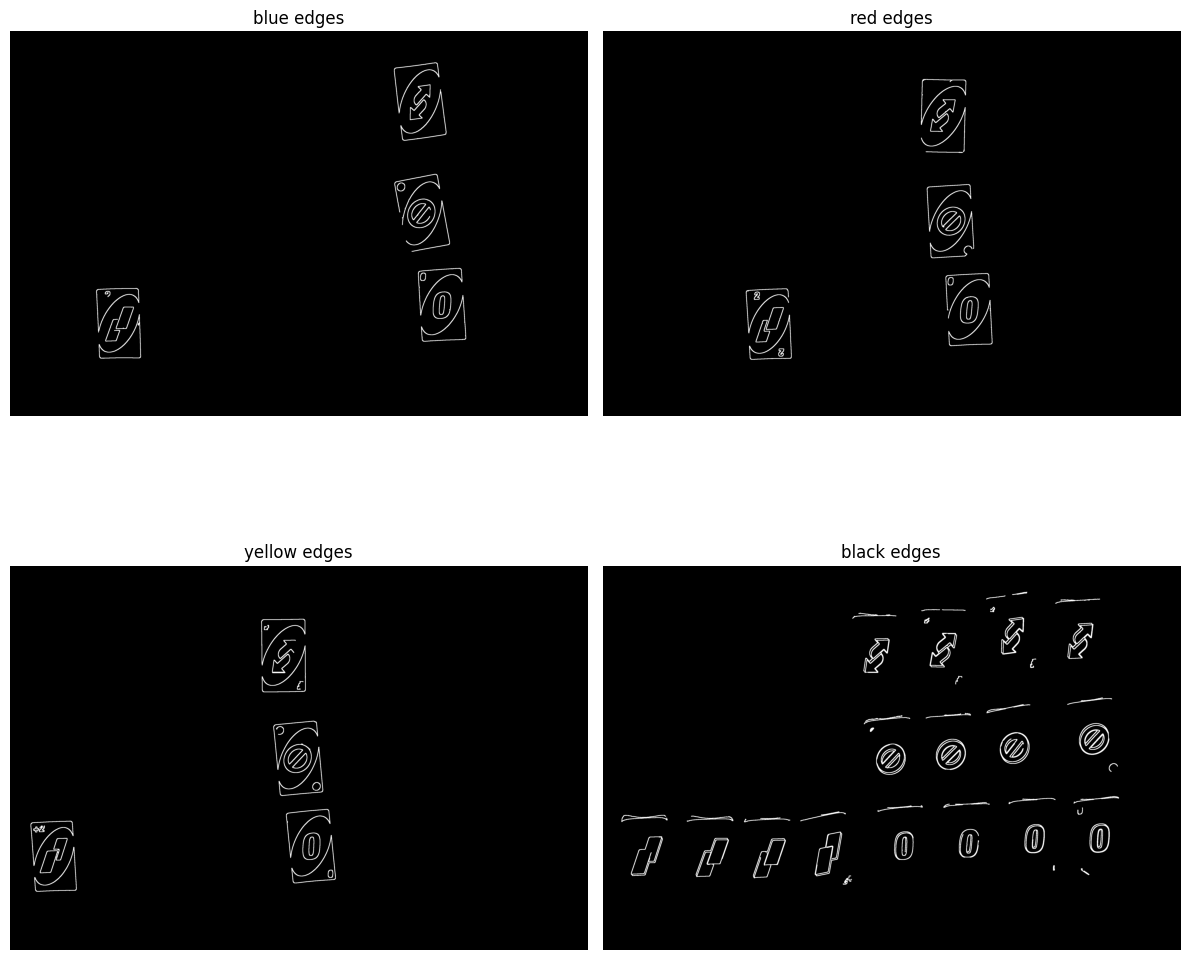

In [25]:
sample_edges = {}
edge_views = []

for color, mask in sample_masks.items():
    edges = canny_mask(mask, canny_settings)
    sample_edges[color] = edges
    edge_views.append((f"{color} edges", edges))

show_images(edge_views, cols=2, figsize=(12, 12))


blue: 4 candidates
red: 3 candidates
yellow: 4 candidates
black: 0 candidates


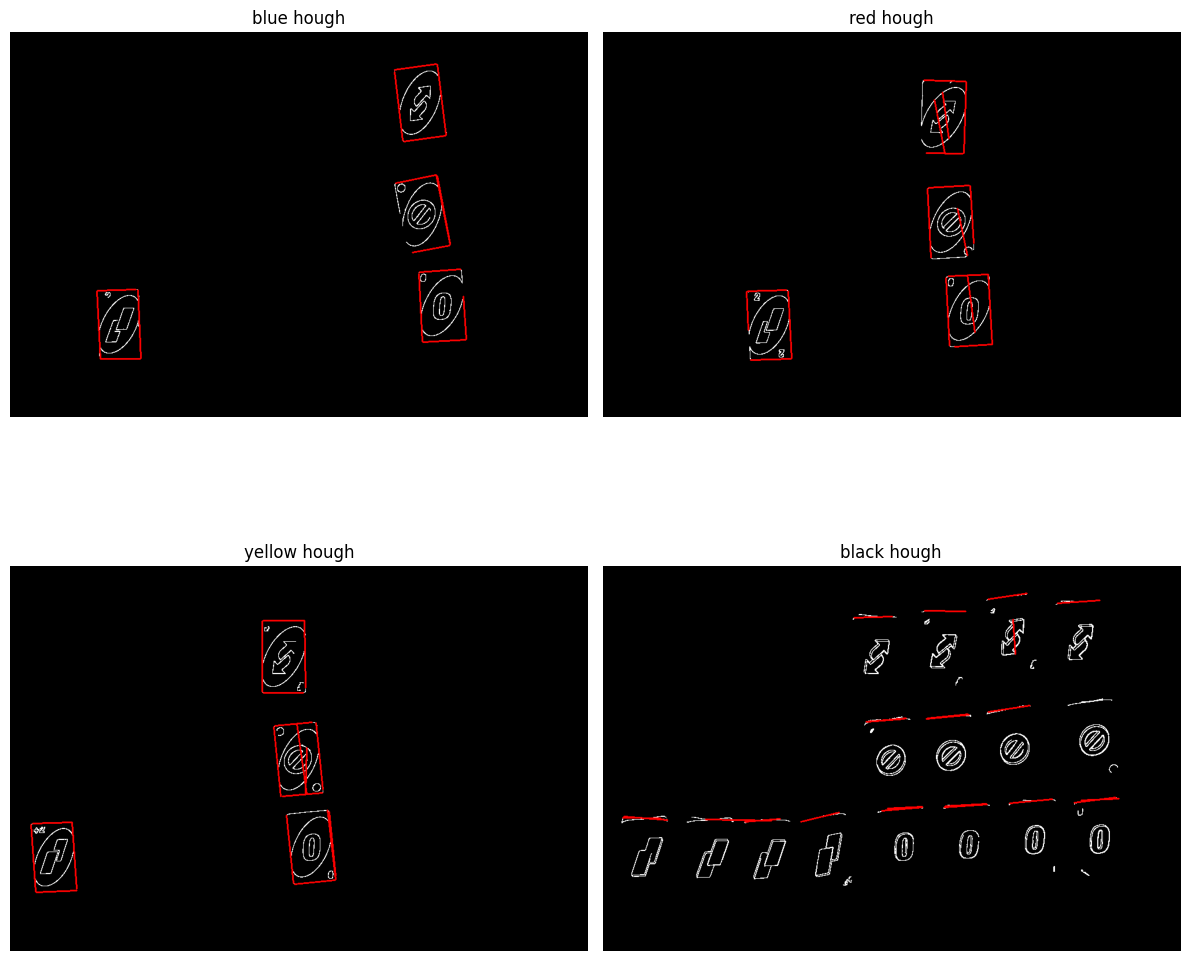

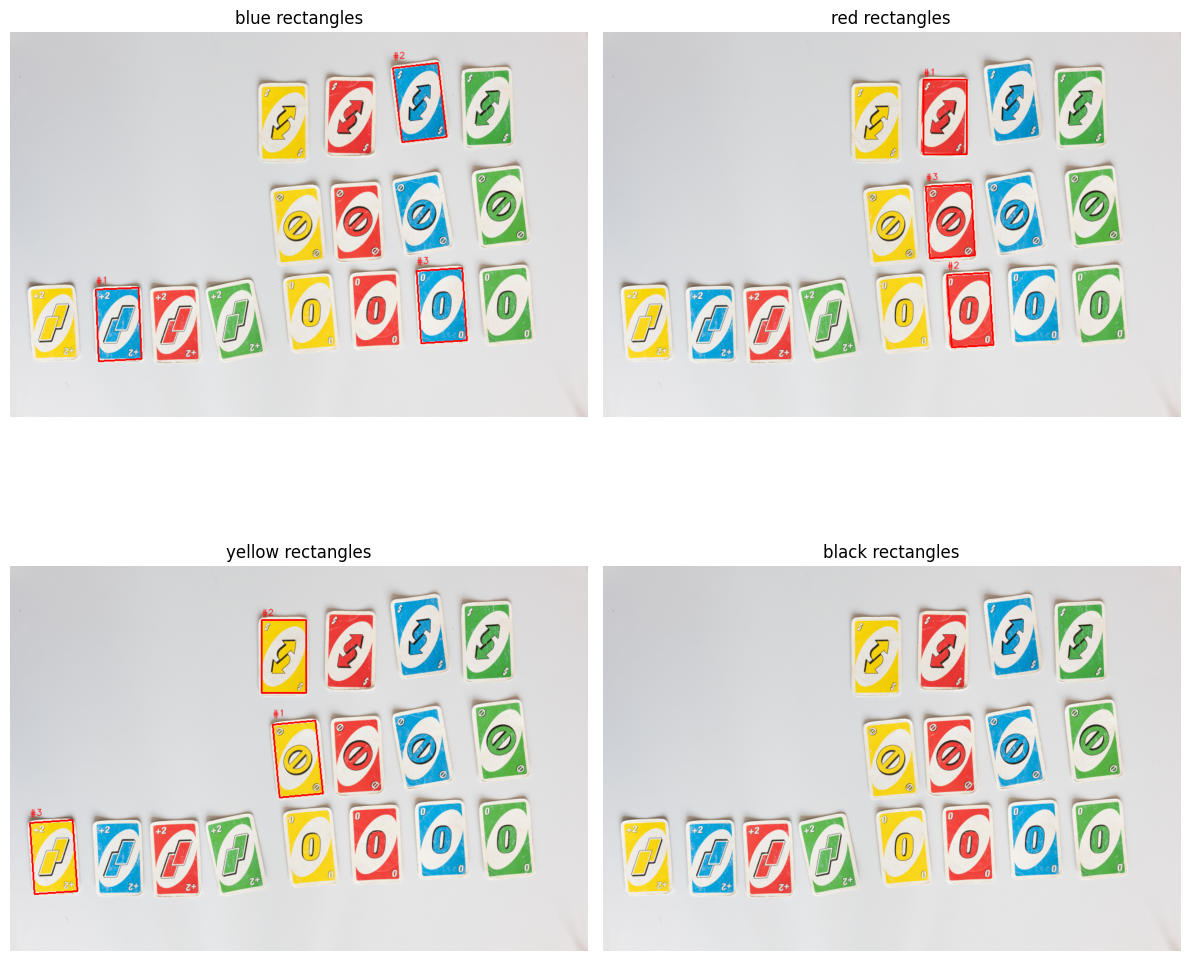

In [26]:
sample_candidates = {}
line_views = []
overlay_views = []

for color, edges in sample_edges.items():
    line_canvas, candidates = detect_rectangles(edges, hough_settings)
    sample_candidates[color] = candidates
    line_views.append((f"{color} hough", line_canvas))

    overlay = cv2.resize(sample_rgb, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_AREA).copy()
    for rank, (_, box, _) in enumerate(candidates[:3], start=1):
        box_int = box.astype(np.int32).reshape(-1, 1, 2)
        x, y, _, _ = cv2.boundingRect(box_int)
        cv2.polylines(overlay, [box_int], True, (255, 0, 0), 2)
        cv2.putText(overlay, f"#{rank}", (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1, cv2.LINE_AA)
    overlay_views.append((f"{color} rectangles", overlay))
    print(f"{color}: {len(candidates)} candidates")

show_images(line_views, cols=2, figsize=(12, 12))
show_images(overlay_views, cols=2, figsize=(12, 12))


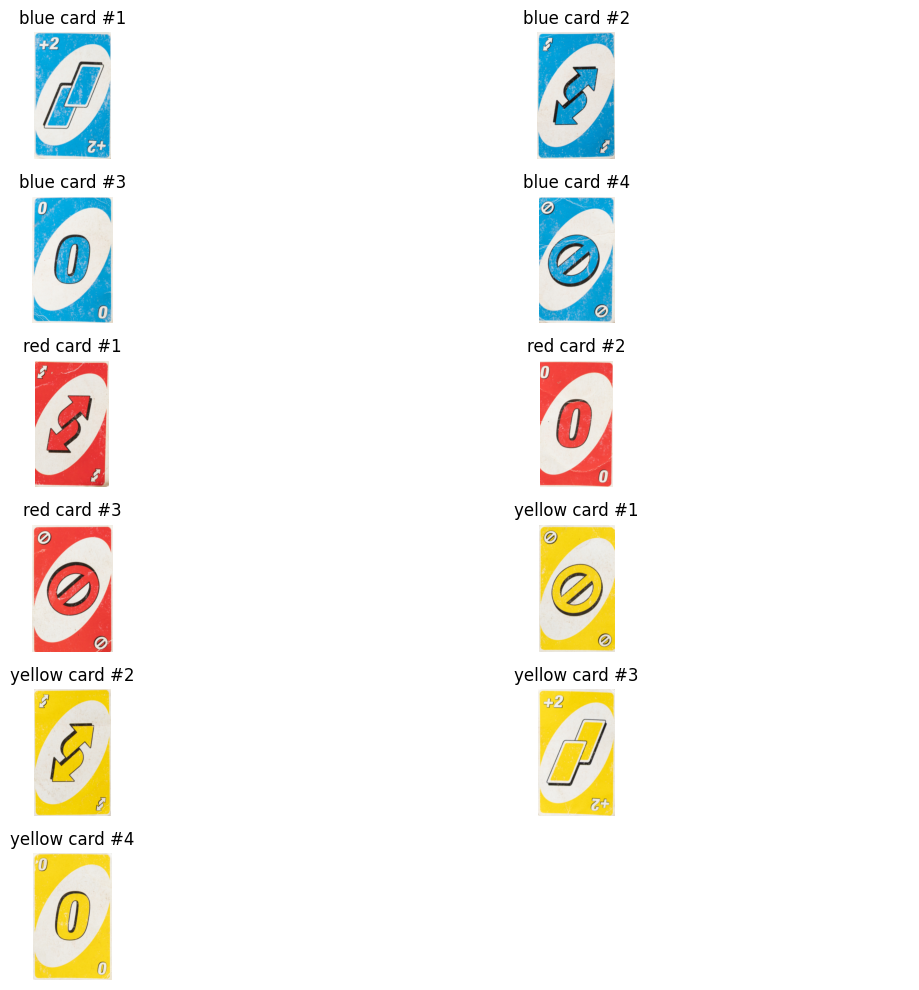

In [27]:
sample_extractions = []

for color, candidates in sample_candidates.items():
    if not candidates:
        continue
    for rank, (_, box, _) in enumerate(candidates, start=1):
        extracted = extract_rotated_rectangle(sample_bgr, box)
        sample_extractions.append((f"{color} card #{rank}", cv2.cvtColor(extracted, cv2.COLOR_BGR2RGB)))

if sample_extractions:
    show_images(sample_extractions, cols=2, figsize=(12, 10))
else:
    print("No sample cards extracted")


In [28]:
saved_cards = []
debug_rows = []

for image_path in images:
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        debug_rows.append((image_path.name, "-", 0, "unreadable image"))
        continue

    for color in COLORS:
        mask = threshold_image(image_bgr, hsv_thresholds[color])
        edges = canny_mask(mask, canny_settings)
        _, candidates = detect_rectangles(edges, hough_settings)
        if not candidates:
            debug_rows.append((image_path.name, color, 0, "no rectangle"))
            continue

        for rank, (score, box, _) in enumerate(candidates, start=1):
            extracted = extract_rotated_rectangle(image_bgr, box)
            output_path = CARDS_DIR / f"{image_path.stem}_{color}_card_{rank:02d}.png"
            if not cv2.imwrite(str(output_path), extracted):
                raise ValueError(f"Could not write extracted card: {output_path}")
            saved_cards.append(output_path)
            debug_rows.append((image_path.name, color, len(candidates), f"saved: {output_path.name} | score={score:.2f}"))

print(f"Saved {len(saved_cards)} extracted cards to {CARDS_DIR}")
for image_name, color, count, status in debug_rows:
    print(f"{image_name:15s} | {color:6s} | candidates={count:2d} | {status}")


Saved 36 extracted cards to c:\Users\Utilisateur\Code\IAPR_gr69\project\iapr-26-uno-vision-challenge\cards
L1000765.jpg    | blue   | candidates= 2 | saved: L1000765_blue_card_01.png | score=56.36
L1000765.jpg    | blue   | candidates= 2 | saved: L1000765_blue_card_02.png | score=46.14
L1000765.jpg    | red    | candidates= 3 | saved: L1000765_red_card_01.png | score=50.37
L1000765.jpg    | red    | candidates= 3 | saved: L1000765_red_card_02.png | score=40.19
L1000765.jpg    | red    | candidates= 3 | saved: L1000765_red_card_03.png | score=36.96
L1000765.jpg    | yellow | candidates= 3 | saved: L1000765_yellow_card_01.png | score=89.05
L1000765.jpg    | yellow | candidates= 3 | saved: L1000765_yellow_card_02.png | score=85.23
L1000765.jpg    | yellow | candidates= 3 | saved: L1000765_yellow_card_03.png | score=55.58
L1000765.jpg    | black  | candidates= 0 | no rectangle
L1000766.jpg    | blue   | candidates= 2 | saved: L1000766_blue_card_01.png | score=244.00
L1000766.jpg    | blue 

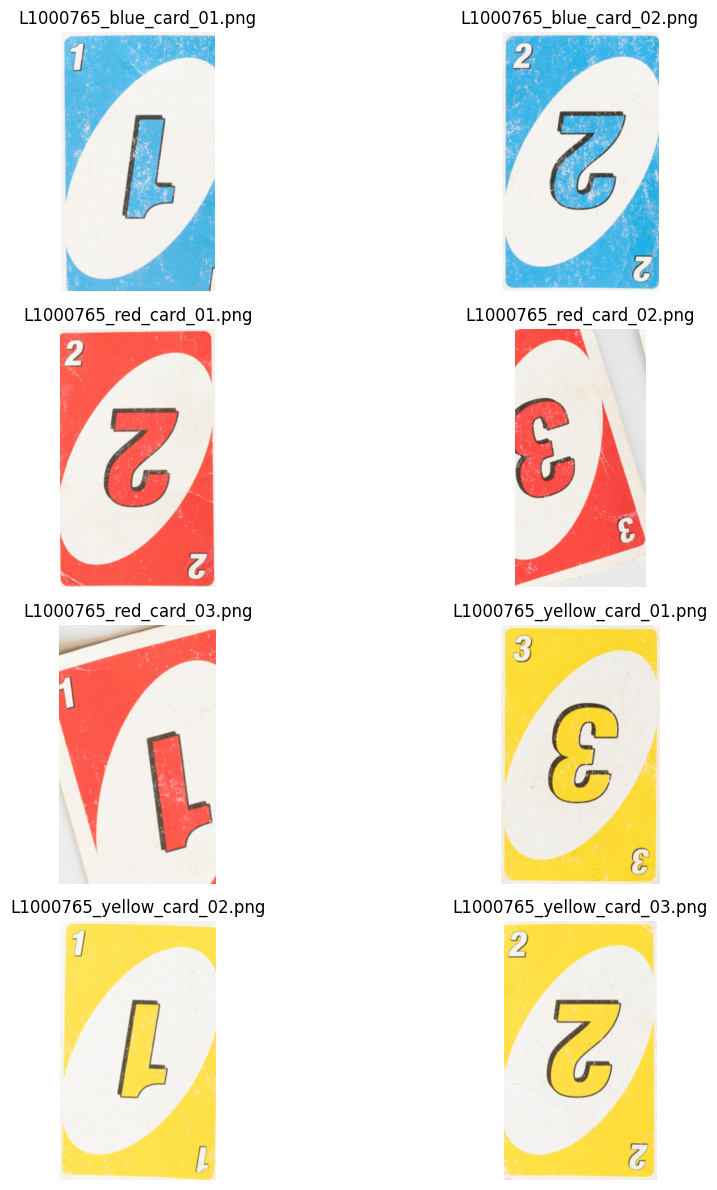

In [29]:
preview_paths = saved_cards[:8]
preview_images = []
for path in preview_paths:
    image_bgr = cv2.imread(str(path))
    if image_bgr is not None:
        preview_images.append((path.name, cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)))

if preview_images:
    show_images(preview_images, cols=2, figsize=(12, 12))
else:
    print("No saved cards to preview")
